<a href="https://colab.research.google.com/github/vikiiiiiiiiiiii/Machine-Learning-Projects/blob/main/ML_Core_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Automatically generate mock Diamond Dataset (Carat, Cut, Color, Clarity -> Price)
print("💎 Generating Diamond Dataset and features...")
np.random.seed(42)
n_samples = 1000

data = {
    'carat': np.random.uniform(0.2, 3.5, n_samples),
    'cut': np.random.choice(['Ideal', 'Premium', 'Very Good', 'Good', 'Fair'], n_samples),
    'color': np.random.choice(['D', 'E', 'F', 'G', 'H', 'I', 'J'], n_samples),
    'clarity': np.random.choice(['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'], n_samples),
}

df_diamonds = pd.DataFrame(data)
# Create a realistic non-linear target price based on the attributes
df_diamonds['price'] = (df_diamonds['carat'] * 4000) + \
                       (df_diamonds['cut'].map({'Ideal':500, 'Premium':400, 'Very Good':300, 'Good':100, 'Fair':0}) * 2) + \
                       np.random.normal(0, 300, n_samples)
df_diamonds['price'] = df_diamonds['price'].clip(lower=300) # Price can't be negative

# 2. Separate Features (X) and Target (y)
X = df_diamonds.drop(columns=['price'])
y = df_diamonds['price']

# 3. Define Categorical and Numerical columns for our Pipeline
numerical_cols = ['carat']
categorical_cols = ['cut', 'color', 'clarity']

# 4. Create Preprocessing Transformers
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Combine them into a single preprocessor bundle using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# 5. Build the complete End-to-End Pipeline with a Random Forest Ensemble
print("⚙️ Building automated preprocessing and modeling pipeline...")
diamond_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42))
])

# 6. Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Train the entire pipeline (Fits transformers and model all in one line!)
print("🚀 Training Random Forest Regressor within the Pipeline framework...")
diamond_pipeline.fit(X_train, y_train)

# 8. Evaluate and run Cross-Validation
predictions = diamond_pipeline.predict(X_test)
r2 = r2_score(y_test, predictions)

print("\n📊 --- PIPELINE PERFORMANCE METRICS ---")
print(f"✅ Test R² Score: {r2:.4f}")

# Perform a quick 3-fold cross validation to demonstrate production robustness
print("🔄 Evaluating 3-Fold Cross-Validation performance...")
cv_scores = cross_val_score(diamond_pipeline, X_train, y_train, cv=3, scoring='r2')
print(f"✅ Mean CV R² Score: {np.mean(cv_scores):.4f}")

💎 Generating Diamond Dataset and features...
⚙️ Building automated preprocessing and modeling pipeline...
🚀 Training Random Forest Regressor within the Pipeline framework...

📊 --- PIPELINE PERFORMANCE METRICS ---
✅ Test R² Score: 0.9913
🔄 Evaluating 3-Fold Cross-Validation performance...
✅ Mean CV R² Score: 0.9894


📈 Simulating sequential financial market data...
🧠 Building LSTM Deep Learning Architecture...
🚀 Training the LSTM model over sequential epochs...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0614 - val_loss: 0.0038
Epoch 2/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0118 - val_loss: 0.0143
Epoch 3/3
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0087 - val_loss: 0.0063

📊 --- DEEP LEARNING MODEL SUMMARY ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,517 (87.96 KB)

 Trainable params: 7,505 (29.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,012 (58.64 KB)

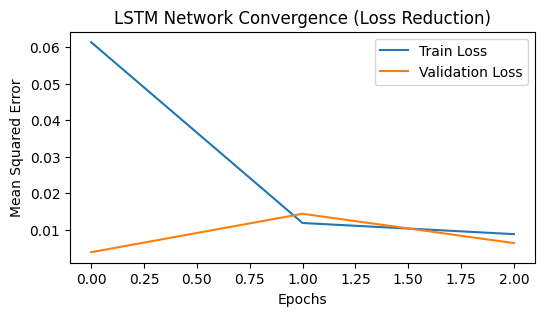

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Generate a mock sequential time-series trend (Simulating historical crypto prices)
print("📈 Simulating sequential financial market data...")
np.random.seed(42)
time_steps = 500
base_trend = np.linspace(10, 50, time_steps)
noise = np.random.normal(0, 2, time_steps)
crypto_prices = base_trend + noise + np.sin(np.linspace(0, 50, time_steps)) * 5
crypto_prices = crypto_prices.reshape(-1, 1)

# 2. Scale features between 0 and 1 using MinMaxScaler (Crucial for Neural Networks)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(crypto_prices)

# 3. Create the sequential lookback windows (LSTM expects 3D format: [samples, time steps, features])
# We will look back at the last 10 days of prices to predict the 11th day
lookback = 10
X, y = [], []
for i in range(lookback, len(scaled_data)):
    X.append(scaled_data[i-lookback:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1)) # Reshaping to 3D for LSTM input layer

# Split into train and validation sets (80% / 20%)
split = int(len(X) * 0.8)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# 4. Construct the Sequential Deep Learning Architecture
print("🧠 Building LSTM Deep Learning Architecture...")
model = Sequential([
    LSTM(units=32, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.1), # Prevents overfitting
    LSTM(units=16, return_sequences=False),
    Dropout(0.1),
    Dense(units=1) # Output layer: predicting the single continuous price for the next day
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# 5. Train the model for 3 quick epochs (Keeps it under 30 seconds!)
print("🚀 Training the LSTM model over sequential epochs...")
history = model.fit(X_train, y_train, epochs=3, batch_size=16, validation_data=(X_val, y_val), verbose=1)

print("\n📊 --- DEEP LEARNING MODEL SUMMARY ---")
model.summary()

# 6. Plot the loss evaluation curve to show convergence
plt.figure(figsize=(6,3))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Network Convergence (Loss Reduction)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

🌍 Simulating country metrics and global development data...
⚙️ Running K-Means Unsupervised Clustering algorithm...

📊 --- UNSUPERVISED CLUSTERING SUMMARY (Cluster Means) ---
                     GDP_per_Capita  Life_Expectancy
Development_Cluster                                 
0                      14842.092778        72.327295
1                      44898.741867        81.096072
2                       1387.351446        59.978755


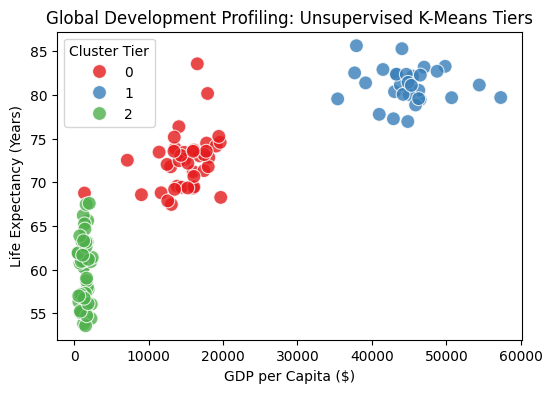

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Automatically generate mock Global Development Indicators (GDP & Life Expectancy)
print("🌍 Simulating country metrics and global development data...")
np.random.seed(42)
n_countries = 120

# Simulate 3 hidden tiers of countries (Developing, Emerging, Developed)
gdp_per_capita = np.concatenate([np.random.normal(1500, 500, 50), np.random.normal(15000, 3000, 40), np.random.normal(45000, 5000, 30)])
life_expectancy = np.concatenate([np.random.normal(60, 4, 50), np.random.normal(72, 3, 40), np.random.normal(81, 2, 30)])

# FIXED FOR MODERN NUMPY: We use explicitly named positional arguments to avoid parsing errors
df_countries = pd.DataFrame({
    'GDP_per_Capita': np.clip(gdp_per_capita, 500, None),
    'Life_Expectancy': np.clip(life_expectancy, 45, None)
})

# 2. Scale features (K-Means is highly sensitive to distance scales!)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_countries)

# 3. Apply Unsupervised Machine Learning: K-Means Clustering
print("⚙️ Running K-Means Unsupervised Clustering algorithm...")
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df_countries['Development_Cluster'] = kmeans.fit_predict(scaled_features)

print("\n📊 --- UNSUPERVISED CLUSTERING SUMMARY (Cluster Means) ---")
print(df_countries.groupby('Development_Cluster').mean())

# 4. Visualize the distinct clusters
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x='GDP_per_Capita',
    y='Life_Expectancy',
    hue='Development_Cluster',
    palette='Set1',
    data=df_countries,
    s=100,
    alpha=0.8
)
plt.title("Global Development Profiling: Unsupervised K-Means Tiers")
plt.xlabel("GDP per Capita ($)")
plt.ylabel("Life Expectancy (Years)")
plt.legend(title="Cluster Tier")
plt.show()